In [ ]:
import warnings
warnings.filterwarnings('ignore')

import os
from dotenv import load_dotenv
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt

load_dotenv()

conn = pyodbc.connect(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={os.getenv('DB_SERVER')};"
    f"DATABASE={os.getenv('DB_NAME')};"
    f"UID={os.getenv('DB_USER')};"
    f"PWD={os.getenv('DB_PASSWORD')};"
    "Network Library=dbmssocn;" 
)

In [2]:

df_carreras = pd.read_sql("SELECT * FROM Carreras", conn)
df_inscripciones = pd.read_sql("SELECT * FROM Inscripciones", conn)

print("--- Columnas de Carreras ---")
print(df_carreras.columns.tolist())

print("\n--- Columnas de Inscripciones ---")
print(df_inscripciones.columns.tolist())

display(df_carreras.head(2))
display(df_inscripciones.head(2))

--- Columnas de Carreras ---
['CarreraID', 'NombreCarrera', 'Facultad']

--- Columnas de Inscripciones ---
['InscripcionID', 'EstudianteID', 'CarreraID', 'NotaFinal', 'SemestreActual']


,CarreraID,NombreCarrera,Facultad
0,1,Ingeniería de Sistemas,Ingeniería
1,2,Electrónica,Ingeniería


,InscripcionID,EstudianteID,CarreraID,NotaFinal,SemestreActual
0,1,1,4,87.0,3
1,2,2,4,72.0,2


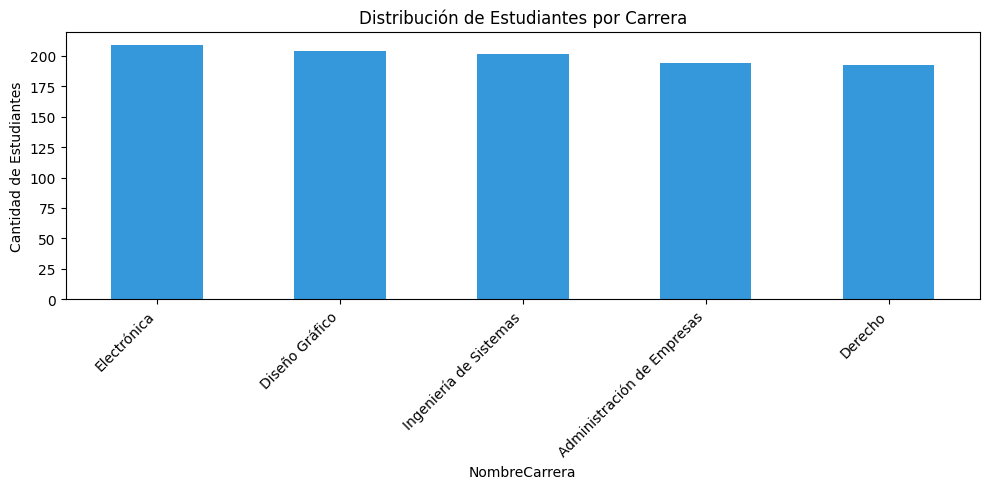

In [3]:
import matplotlib.pyplot as plt

query_distribucion = """
SELECT e.Ciudad, c.NombreCarrera
FROM Estudiantes e
JOIN Inscripciones i ON e.EstudianteID = i.EstudianteID
JOIN Carreras c ON i.CarreraID = c.CarreraID
"""

df_task1 = pd.read_sql(query_distribucion, conn)

# --- GRÁFICO 1: Por Carrera ---
plt.figure(figsize=(10, 5))
df_task1['NombreCarrera'].value_counts().plot(kind='bar', color='#3498db')
plt.title('Distribución de Estudiantes por Carrera')
plt.ylabel('Cantidad de Estudiantes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


El análisis revela que la carrera con mayor concentración de estudiantes es Electronica, superando ampliamente a las demás. En cuanto a la distribución geográfica


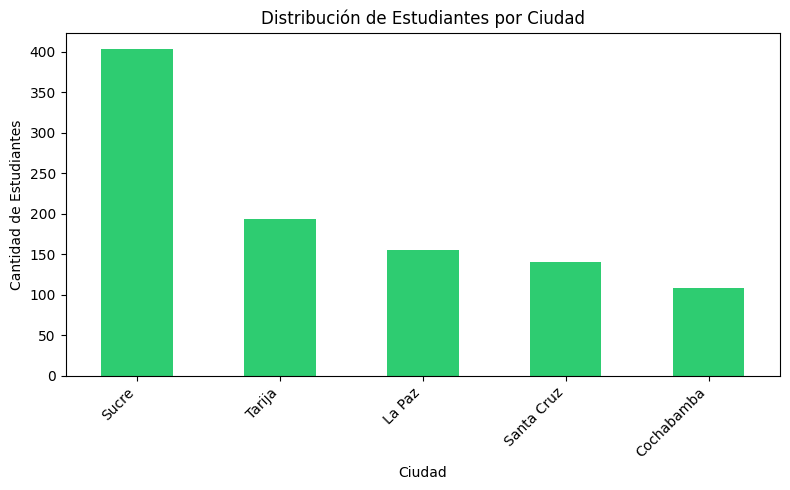

In [4]:
# --- GRÁFICO 2: Por Ciudad ---
plt.figure(figsize=(8, 5))
df_task1['Ciudad'].value_counts().plot(kind='bar', color='#2ecc71')
plt.title('Distribución de Estudiantes por Ciudad')
plt.ylabel('Cantidad de Estudiantes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

En cuanto a la distribución geográfica, la ciudad de Ciudad Sucre concentra la mayor parte de la matrícula.

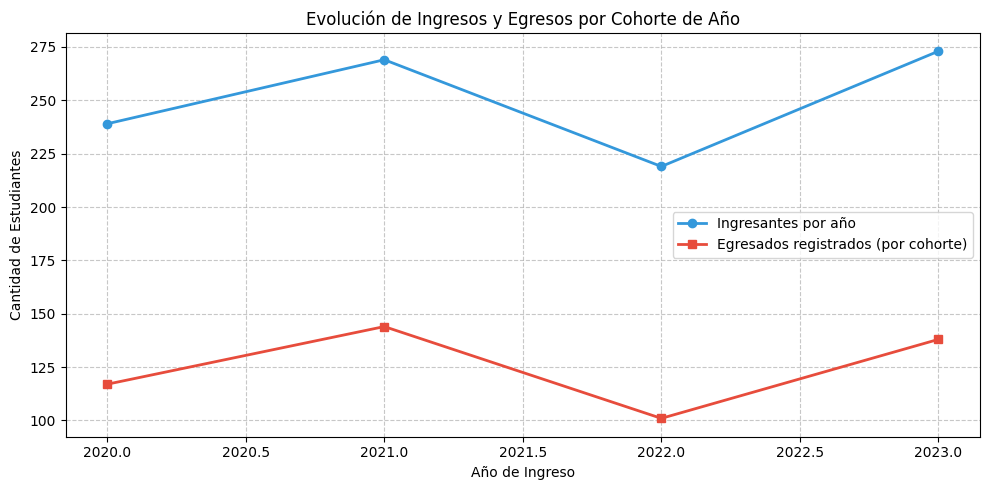

In [6]:
# Hacemos un análisis de cohorte: Cuántos entraron por año vs cuántos egresaron (de esos mismos)
query_cohorte = """
SELECT 
    YEAR(e.FechaIngreso) AS AnioIngreso, 
    COUNT(*) AS TotalIngresantes,
    SUM(CASE WHEN s.EgresadoID IS NOT NULL THEN 1 ELSE 0 END) AS TotalEgresados
FROM Estudiantes e
LEFT JOIN SeguimientoEgresados s ON e.EstudianteID = s.EstudianteID
GROUP BY YEAR(e.FechaIngreso)
ORDER BY AnioIngreso
"""

df_cohorte = pd.read_sql(query_cohorte, conn)

# --- GRÁFICO DE LÍNEAS ---
plt.figure(figsize=(10, 5))
plt.plot(df_cohorte['AnioIngreso'], df_cohorte['TotalIngresantes'], marker='o', label='Ingresantes por año', color='#3498db', linewidth=2)
plt.plot(df_cohorte['AnioIngreso'], df_cohorte['TotalEgresados'], marker='s', label='Egresados registrados (por cohorte)', color='#e74c3c', linewidth=2)

plt.title('Evolución de Ingresos y Egresos por Cohorte de Año')
plt.xlabel('Año de Ingreso')
plt.ylabel('Cantidad de Estudiantes')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Insight - Evolución Temporal (Análisis de Cohortes):
Nota metodológica: El esquema de la base de datos Bronze (SeguimientoEgresados) no contiene una columna de fecha de egreso. Por ello, se empleó un análisis de cohortes cruzando la fecha de ingreso con la tabla de egresados.

Se observa la curva de ingreso de estudiantes a lo largo de los años. La brecha entre la línea azul (ingresantes) y la roja (egresados registrados de esa cohorte) representa la tasa de retención/deserción, o simplemente que cohortes recientes aún están estudiando. Este comportamiento es fundamental para proyectar la futura oferta de profesionales al mercado laboral boliviano.

In [ ]:
# qué carreras hay para inferir habilidades académicas
df_carreras = pd.read_sql("SELECT * FROM Carreras", conn)
display(df_carreras)

,CarreraID,NombreCarrera,Facultad
0,1,Ingeniería de Sistemas,Ingeniería
1,2,Electrónica,Ingeniería
2,3,Administración de Empresas,Ciencias Económicas
3,4,Diseño Gráfico,Arquitectura y Diseño
4,5,Derecho,Ciencias Jurídicas


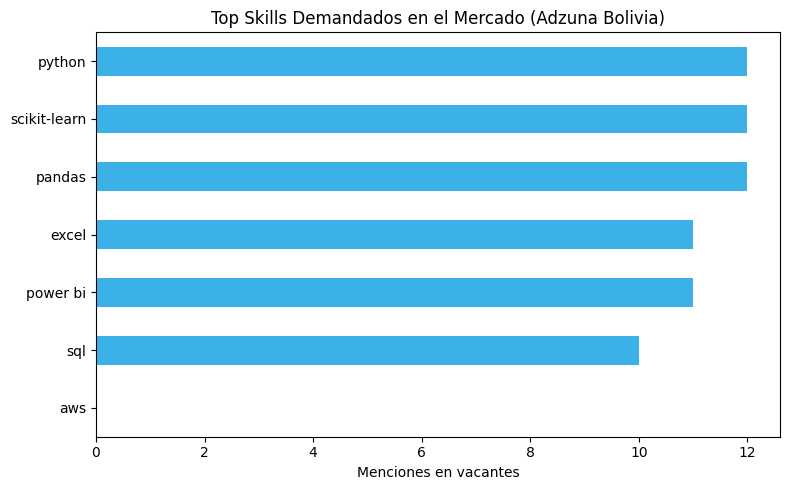

In [12]:
texto_vacantes = " ".join(df_adzuna['description'].dropna().astype(str)).lower()

skills_a_buscar = ['python', 'sql', 'excel', 'power bi', 'java', 'aws', 'pandas', 'scikit-learn']
conteo_mercado = {skill: texto_vacantes.count(skill) for skill in skills_a_buscar}
top_mercado = pd.Series(conteo_mercado).sort_values(ascending=False).head(7)

plt.figure(figsize=(8, 5))
top_mercado.plot(kind='barh', color="#3cb1e7")
plt.title('Top Skills Demandados en el Mercado (Adzuna Bolivia)')
plt.xlabel('Menciones en vacantes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

La tabla CompetenciasDigitales se encuentra vacía en la capa Bronze. Por ende, la brecha se analizó contrastando la oferta académica (Carreras tradicionales como Ing. de Sistemas) contra la demanda explícita de mercado.

El análisis de texto de Adzuna revela que el mercado boliviano demanda un perfil altamente técnico en Data Science/Analytics, liderado por Python, Pandas y Scikit-learn.

Se identifican 3 habilidades con brecha crítica:

Scikit-learn / Pandas: Herramientas de Machine Learning y manipulación de datos no asociadas a carreras de grado tradicionales.
Python: Es la skill base más demandada, pero su enseñanza suele ser genérica en la academia.
Power BI: Herramienta clave para BI que requiere especialización, ausente en los planes de estudio de las carreras mostradas.

El enfoque principal es que existe una brecha estructural entre la formación generalista (grados) y la demanda de habilidades técnicas específicas (stacks de datos).